Model **Training**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import datetime
import warnings
import nltk
import random
import re
import sklearn
import zipfile
!pip install gensim
import gensim
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 92.1 MB/s eta 0:00:00


# Importing Dataset

In [ ]:
news_data = pd.read_csv("FakeNewsNet.csv")
news_data.dropna(inplace=True)
news_data.reset_index(inplace=True)
news_data.drop(["index","news_url","source_domain","tweet_num"],axis=1,inplace=True)
news_data.head()

,title,real
0,Kandi Burruss Explodes Over Rape Accusation on...,1
1,People's Choice Awards 2018: The best red carp...,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,1
3,Colombian singer Maluma sparks rumours of inap...,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,1


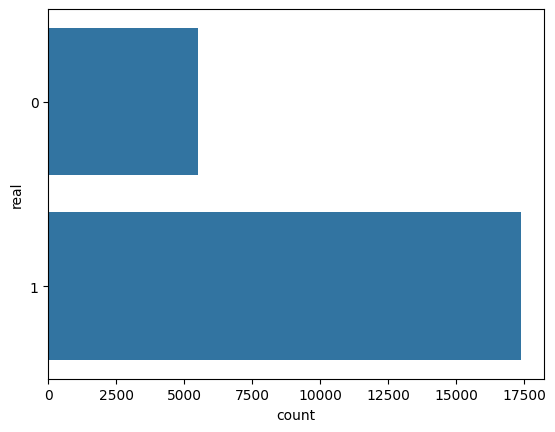

In [ ]:
sns.countplot(data = news_data,y="real");

# Text Preprocessing

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
stopwords = nltk.corpus.stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
lemmatizer = nltk.stem.WordNetLemmatizer()

def lemTitles(title):
    words = nltk.word_tokenize(title)
    words = [re.sub("[^a-zA-Z0-9]","",i).lower().strip() for i in words]
    words = [lemmatizer.lemmatize(i) for i in words if i not in stopwords]
    title = " ".join(words)
    return title

news_data["title"] = news_data["title"].apply(lemTitles)
news_data.head()

,title,real
0,kandi burruss explodes rape accusation real ho...,1
1,people choice award 2018 best red carpet look,1
2,sophia bush sends sweet birthday message one t...,1
3,colombian singer maluma spark rumour inappropr...,1
4,gossip girl 10 year later upper east siders s...,1


In [ ]:
VOCAB_SIZE = 10000
DIMENSION = 100
MAXLEN = 20

In [ ]:
def oneHot(title):
    return tf.keras.preprocessing.text.one_hot(title,VOCAB_SIZE)

news_data["title"] = news_data["title"].apply(oneHot)

In [ ]:
news_data.head()

,title,real
0,"[5639, 6410, 5606, 8481, 6738, 8162, 4255, 791...",1
1,"[5624, 4745, 8433, 2329, 5748, 5761, 796, 4922]",1
2,"[3690, 9753, 4612, 9817, 4186, 2519, 1846, 845...",1
3,"[984, 5637, 5936, 3433, 6323, 9810, 3599, 6142]",1
4,"[1174, 7665, 5829, 4758, 8148, 2737, 7358, 192...",1


In [ ]:
news_data.shape

(22866, 2)

In [ ]:
df = pd.DataFrame(tf.keras.utils.pad_sequences(news_data["title"],padding="pre",maxlen=MAXLEN))
df.shape

(22866, 20)

In [ ]:
news_data = pd.concat((news_data,df),axis=1)
news_data.shape

(22866, 22)

In [ ]:
news_data.head(10)

,title,real,0,1,2,3,4,5,6,7,...,10,11,12,13,14,15,16,17,18,19
0,"[5639, 6410, 5606, 8481, 6738, 8162, 4255, 791...",1,0,0,0,0,0,0,0,0,...,5639,6410,5606,8481,6738,8162,4255,7915,6687,1993
1,"[5624, 4745, 8433, 2329, 5748, 5761, 796, 4922]",1,0,0,0,0,0,0,0,0,...,0,0,5624,4745,8433,2329,5748,5761,796,4922
2,"[3690, 9753, 4612, 9817, 4186, 2519, 1846, 845...",1,0,0,0,0,0,0,3690,9753,...,4186,2519,1846,8458,6748,3287,8878,4183,3742,9024
3,"[984, 5637, 5936, 3433, 6323, 9810, 3599, 6142]",1,0,0,0,0,0,0,0,0,...,0,0,984,5637,5936,3433,6323,9810,3599,6142
4,"[1174, 7665, 5829, 4758, 8148, 2737, 7358, 192...",1,0,0,0,0,0,0,1174,7665,...,8148,2737,7358,1922,8756,7385,4599,2653,3285,3581
5,"[8588, 2721, 9609, 3274, 7838, 3332, 8258, 584...",0,0,0,0,0,0,0,0,0,...,0,8588,2721,9609,3274,7838,3332,8258,5842,4511
6,"[5329, 6488, 3675, 8620, 6664, 4686]",0,0,0,0,0,0,0,0,0,...,0,0,0,0,5329,6488,3675,8620,6664,4686
7,"[8393, 9197, 4854, 3692, 2192, 2581, 6006, 523...",0,0,0,0,0,0,0,0,0,...,8393,9197,4854,3692,2192,2581,6006,5237,9876,5216
8,"[2611, 3790, 6831, 6576, 598, 1185, 7497, 8234...",1,0,0,0,0,0,0,0,0,...,2611,3790,6831,6576,598,1185,7497,8234,788,8792
9,"[1761, 3536, 171, 5001, 5710, 7626]",1,0,0,0,0,0,0,0,0,...,0,0,0,0,1761,3536,171,5001,5710,7626


# Model Creation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,roc_auc_score,precision_score, confusion_matrix

cols = [i for i in range(0,20)]
seed = np.random.seed(6)

X = news_data[cols]
y = news_data["real"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25,random_state=seed)

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Embedding(VOCAB_SIZE,DIMENSION,input_length=len(cols)))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128,return_sequences=True)))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128)))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(1,activation="sigmoid"))
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
earlyStopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=3,start_from_epoch=5,restore_best_weights=True,)

history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=20,batch_size=64, callbacks=[earlyStopping])

Epoch 1/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7707 - loss: 0.5076 - val_accuracy: 0.8398 - val_loss: 0.3767
Epoch 2/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8619 - loss: 0.3139 - val_accuracy: 0.8379 - val_loss: 0.3887
Epoch 3/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8994 - loss: 0.2455 - val_accuracy: 0.8303 - val_loss: 0.4288
Epoch 4/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9280 - loss: 0.1788 - val_accuracy: 0.8191 - val_loss: 0.5264
Epoch 5/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9448 - loss: 0.1333 - val_accuracy: 0.8092 - val_loss: 0.5824
Epoch 6/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9493 - loss: 0.1158 - val_accuracy: 0.8149 - val_loss: 0.6793
Epoch 7/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9635 - loss: 0.0889 - val_accuracy: 0.8090 - val_loss: 0.8103
Epoch 8/20
268/268 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9672 - loss: 0.0755 - val_acc

# Model Evaluation

In [ ]:
df = pd.DataFrame(history.history)
df_loss = df[['loss', 'val_loss']]
df_acc =  df[['accuracy', 'val_accuracy']]

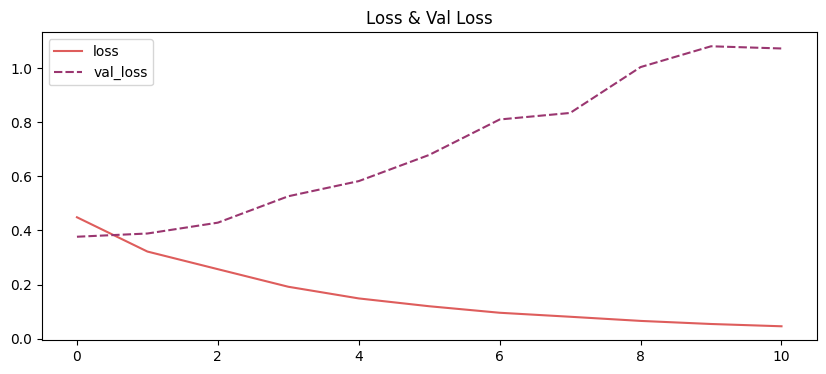

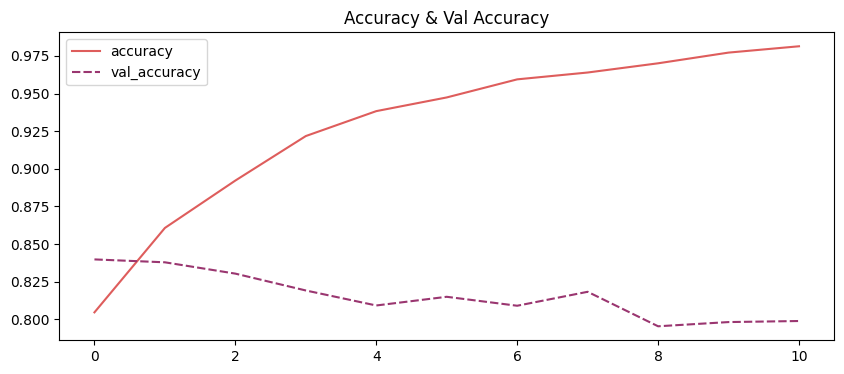

In [ ]:
plt.figure(figsize=(10, 4))
plt.title("Loss & Val Loss")
sns.lineplot(df_loss,palette="flare");

plt.figure(figsize=(10, 4))
plt.title("Accuracy & Val Accuracy")
sns.lineplot(df_acc,palette="flare");

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


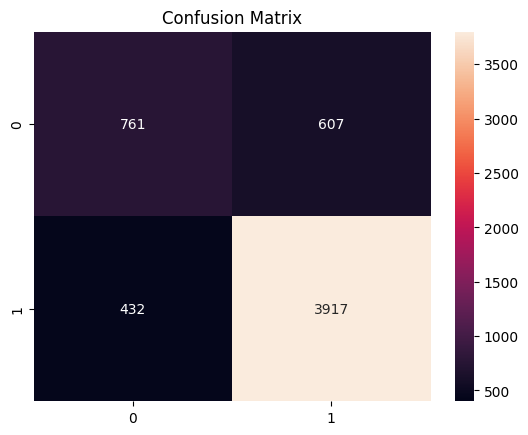

In [ ]:
threshold = 0.5
y_pred = (model.predict(X_test) > threshold).astype("int32")
cnf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(cnf_matrix,annot=True,cmap="rocket",fmt=".5g",vmin=400,vmax=3800)
plt.title("Confusion Matrix");